In [6]:
%pip install pygad


   -------------------- ------------------- 1/2 [pygad]
   -------------------- ------------------- 1/2 [pygad]
   ---------------------------------------- 2/2 [pygad]

Note: you may need to restart the kernel to use updated packages.


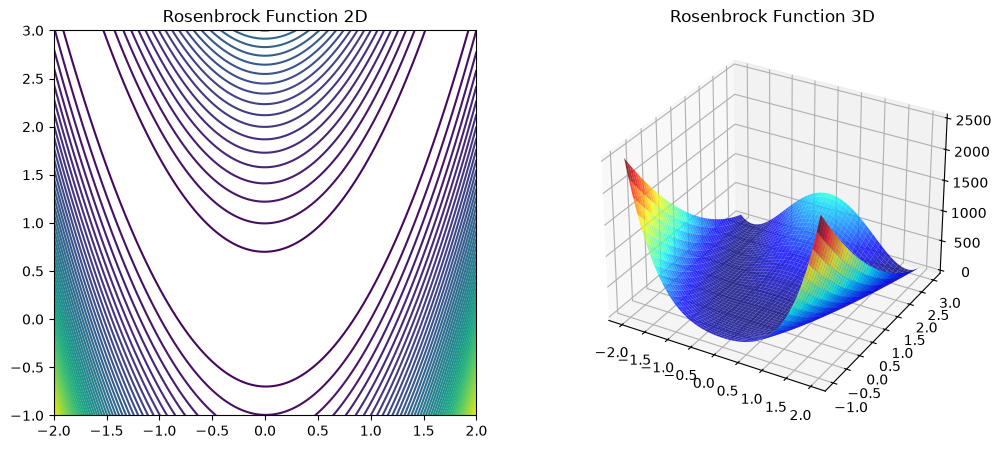

Initial guess [1.2, -1.7], Result: [0.99999529 0.99999056], Value: 2.221424627751278e-11, Success: True, Iterations: 15, Time: 0.0170 sec
Initial guess [1.9, 2.3], Result: [0.99999578 0.99999155], Value: 1.7807672125623847e-11, Success: True, Iterations: 19, Time: 0.0132 sec
Initial guess [0.9, 1.5], Result: [0.9999961  0.99999226], Value: 1.5578569439828763e-11, Success: False, Iterations: 17, Time: 0.0155 sec


c:\Users\loges\miniconda3\envs\mude-base\Lib\site-packages\pygad\utils\validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


PyGAD initial guess [1.2, -1.7], Solution: [1.00911156 1.01844056], Value: 8.482746448692457e-05, iterations: 2000, Time: 0.7445 sec
PyGAD initial guess [1.9, 2.3], Solution: [1.00351836 1.00708944], Value: 1.2541617350654197e-05, iterations: 2000, Time: 0.6620 sec
PyGAD initial guess [0.9, 1.5], Solution: [0.99537663 0.99082997], Value: 2.16818526687128e-05, iterations: 2000, Time: 0.6262 sec


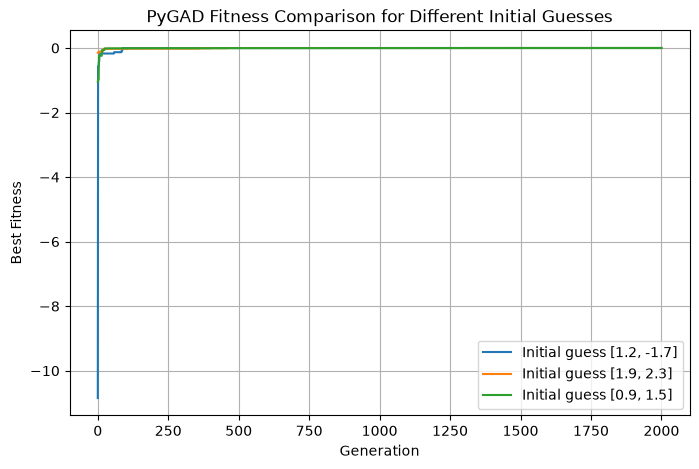

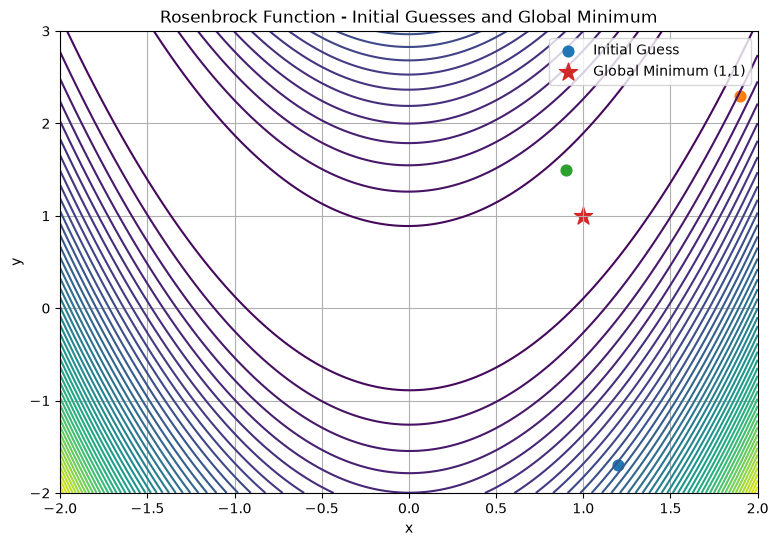

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")

plt.show()


# Scipy Optimization
init_guesses = [[1.2, -1.7], [1.9, 2.3], [0.9, 1.5]]

for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()

    elapsed_time = end_time - start_time

    print(f"Initial guess {guess}, Result: {result.x}, "
          f"Value: {result.fun}, Success: {result.success}, "
          f"Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")


# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution)  # pygad maximizes, so negate


# Create ONE figure for all 3 PyGAD results
plt.figure(figsize=(8,5))

for guess in init_guesses:

    start_time = time.perf_counter()

    ga_instance = pygad.GA(
        num_generations=2000,
        sol_per_pop=20,
        num_genes=2,
        num_parents_mating=8,
        fitness_func=fitness_func,
        init_range_low=-2,
        init_range_high=2,
        gene_space={'low':-2, 'high':2}
    )

    ga_instance.run()

    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    print(f"PyGAD initial guess {guess}, "
          f"Solution: {solution}, "
          f"Value: {rosenbrock(solution)}, "
          f"iterations: {iters}, "
          f"Time: {elapsed_time:.4f} sec")

    # Add this result to the SAME graph
    plt.plot(
        ga_instance.best_solutions_fitness,
        label=f"Initial guess {guess}"
    )


# Final combined graph
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("PyGAD Fitness Comparison for Different Initial Guesses")
plt.legend()
plt.grid()
plt.show()

x_range_final = np.linspace(-2, 2, 400)
y_range_final = np.linspace(-2, 3, 400)

X_final, Y_final = np.meshgrid(x_range_final, y_range_final)
Z_final = rosenbrock([X_final, Y_final])

plt.figure(figsize=(9, 6))

# Contour plot
plt.contour(X_final, Y_final, Z_final, levels=50)

# Plot initial guesses
for i, guess in enumerate(init_guesses):
    plt.scatter(
        guess[0],
        guess[1],
        s=60,
        label="Initial Guess" if i == 0 else ""
    )

# Global minimum
plt.scatter(
    1,
    1,
    marker='*',
    s=180,
    label="Global Minimum (1,1)"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Rosenbrock Function - Initial Guesses and Global Minimum")
plt.legend()
plt.grid()

plt.show()

Problem 1 – Rosenbrock Function


(1) scipy.optimize

The BFGS method was used with three initial guesses:
(1.2,-1.7)
(1.9,2.3)
(0.9,1.5)

For all three initial guesses, the solution converged approximately to:

x=1,y=1

and

f(x,y)==0

Observation: Changing the initial guess did not significantly change the final solution.

Conclusion: The obtained solution is the global minimum of the Rosenbrock function at (1,1).



(2) Genetic Algorithm using PyGAD

The Rosenbrock function was minimized using the PyGAD genetic algorithm.

The same three initial guesses were considered for comparison.

The solutions obtained were close to:

 x=1,y=1

with the Rosenbrock function value close to zero.

Observation: The genetic algorithm also converged towards the global minimum, although the exact result may vary slightly because the genetic algorithm uses random operations.

Conclusion: The Genetic Algorithm was able to find the global minimum near (1,1).



(3) Comparison

| Parameter | BFGS | PyGAD |
|---|---|---|
| Method | Gradient-based | Non-gradient-based |
| Solution | Near (1,1) | Near (1,1) |
| Function value | Near 0 | Near 0 |
| Iterations | Lower | Higher |
| Time | Lower | Higher |
| Minimum | Global | Global |

Final conclusion: Both methods found the global minimum of the Rosenbrock function. BFGS was faster and required fewer iterations, while PyGAD required more generations because it is a population-based genetic algorithm.

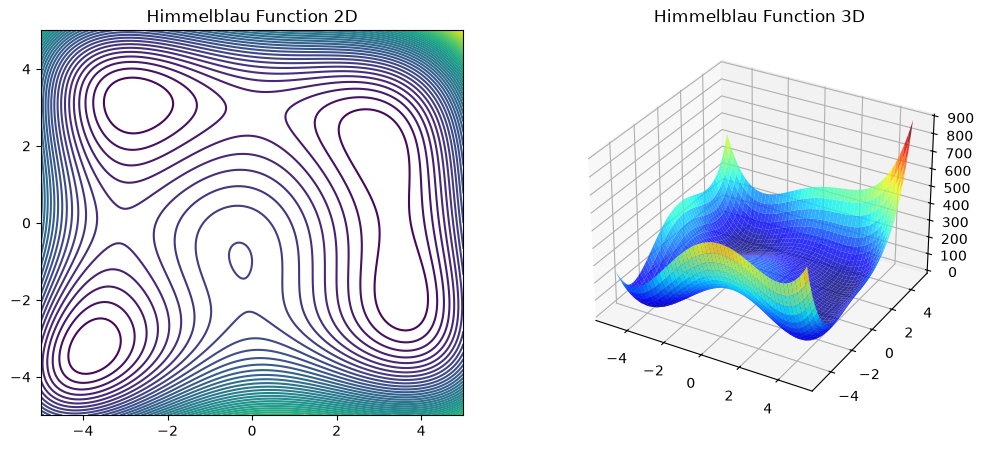

Initial guess [4, -9], Result: [ 3.58442832 -1.84812654], Value: 3.677725473267505e-14, Success: True, Iterations: 17, Time: 0.0043 sec
Initial guess [7.3, 4.6], Result: [2.99999999 2.        ], Value: 2.2646444560709627e-15, Success: True, Iterations: 15, Time: 0.0055 sec
Initial guess [2.9, -5], Result: [ 3.58442833 -1.84812654], Value: 4.230547288023155e-15, Success: True, Iterations: 12, Time: 0.0021 sec
PyGAD initial guess [4, -9], Solution: [2.98762075 2.00758353], Value: 0.004751849258878018, Iterations: 300, Time: 0.1351 sec
PyGAD initial guess [7.3, 4.6], Solution: [ 3.57995091 -1.8500051 ], Value: 0.001159146860480443, Iterations: 300, Time: 0.1706 sec
PyGAD initial guess [2.9, -5], Solution: [ 3.58809426 -1.85139079], Value: 0.0007781771178178936, Iterations: 300, Time: 0.1530 sec


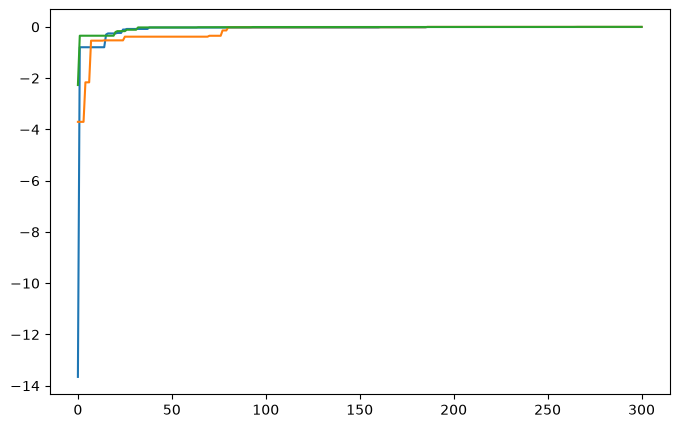

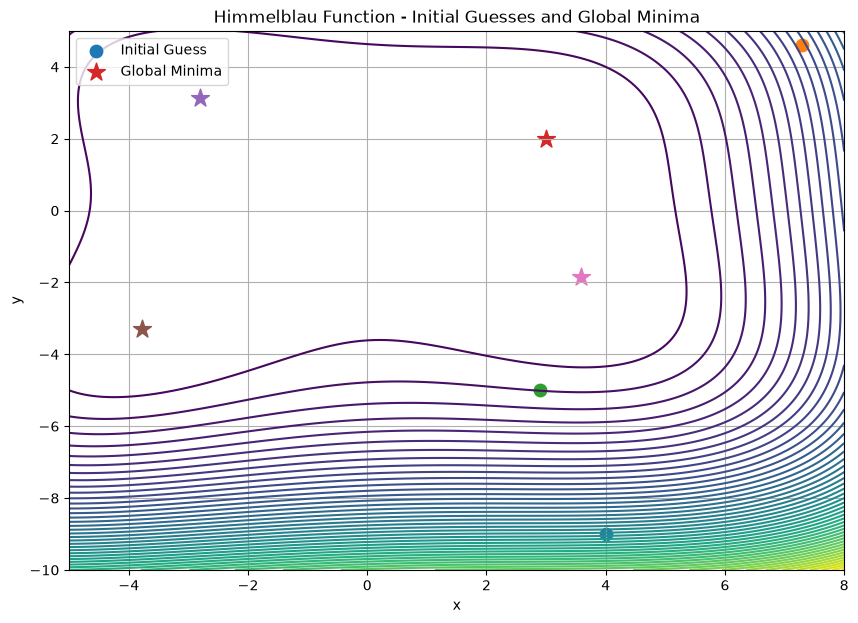

In [7]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Himmelblau function
def himmelblau(x):
    x = np.asarray(x)  # Convert to numpy array
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2


# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")

plt.show()


# Scipy Optimization
init_guesses = [[4, -9], [7.3, 4.6], [2.9, -5]]

for guess in init_guesses:
    start_time = time.perf_counter()

    result = minimize(himmelblau, guess, method='BFGS')

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    print(f"Initial guess {guess}, "
          f"Result: {result.x}, "
          f"Value: {result.fun}, "
          f"Success: {result.success}, "
          f"Iterations: {result.nit}, "
          f"Time: {elapsed_time:.4f} sec")


# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)


# Create ONE graph for all 3 initial guesses
plt.figure(figsize=(8,5))

for guess in init_guesses:

    start_time = time.perf_counter()

    ga_instance = pygad.GA(
        num_generations=300,
        sol_per_pop=30,
        num_genes=2,
        num_parents_mating=12,
        fitness_func=fitness_func2,
        init_range_low=-5,
        init_range_high=5,
        gene_space={'low':-5, 'high':5}
    )

    ga_instance.run()

    solution, solution_fitness, _ = ga_instance.best_solution()

    end_time = time.perf_counter()
    elapsed_time = end_time - start_time

    print(f"PyGAD initial guess {guess}, "
          f"Solution: {solution}, "
          f"Value: {himmelblau(solution)}, "
          f"Iterations: {ga_instance.generations_completed}, "
          f"Time: {elapsed_time:.4f} sec")

    # Add each result to the SAME graph
    plt.plot(
        ga_instance.best_solutions_fitness,
        label=f"Initial guess {guess}"
    )


# Use a wider range so that all initial guesses are visible
x_final = np.linspace(-5, 8, 500)
y_final = np.linspace(-10, 5, 500)

X_final, Y_final = np.meshgrid(x_final, y_final)
Z_final = himmelblau([X_final, Y_final])

plt.figure(figsize=(10, 7))

# Contour plot
plt.contour(X_final, Y_final, Z_final, levels=50)

# Plot initial guesses
for i, guess in enumerate(init_guesses):
    plt.scatter(
        guess[0],
        guess[1],
        s=80,
        label="Initial Guess" if i == 0 else ""
    )

# Four global minima
global_minima = [
    (3, 2),
    (-2.805, 3.131),
    (-3.779, -3.283),
    (3.584, -1.848)
]

for i, minimum in enumerate(global_minima):
    plt.scatter(
        minimum[0],
        minimum[1],
        marker='*',
        s=180,
        label="Global Minima" if i == 0 else ""
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Himmelblau Function - Initial Guesses and Global Minima")
plt.legend()
plt.grid()

plt.show()

Problem 2 – Himmelblau Function

(1) Optimization using scipy.optimize

The BFGS method was used with three different initial guesses:

- (4, -9)
- (7.3, 4.6)
- (2.9, -5)

The optimization was performed for each initial guess.

The Himmelblau function has multiple global minima. Therefore, changing the initial guess can lead to different minimum points.

Observation

The three initial guesses can converge to different minimum points. However, the function value at each global minimum is approximately zero.

Conclusion

The solutions obtained correspond to the global minima* of the Himmelblau function, although the minimum point may change depending on the initial guess.



(2) Optimization using Genetic Algorithm

The Himmelblau function was also minimized using the Genetic Algorithm implemented using PyGAD.

The same three initial guesses were considered for comparison.

Observation

The Genetic Algorithm converged towards one of the global minimum regions of the Himmelblau function. Since the genetic algorithm uses random operations, the exact solution may vary between runs.

Conclusion

The Genetic Algorithm was able to find a global minimum of the Himmelblau function, with the function value approaching zero.



(3) Comparison

| Parameter | BFGS | PyGAD |
|---|---|---|
| Method | Gradient-based | Non-gradient-based |
| Solution | Global minimum | Global minimum |
| Function value | Near 0 | Near 0 |
| Iterations | Lower | Higher |
| Time | Lower | Higher |
| Minimum | Global | Global |